### **Complete Pipeline Summary**

**`Dataset → Cleaning → Encoding
→ Train/Test Split → Scaling → Model Training
→ Prediction → Evaluation`**


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [18]:
df = pd.read_csv('dataset/Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [19]:
df.shape

(10000, 6)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [21]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [22]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(127)

In [24]:
df=df.drop_duplicates()

In [25]:
# after removing duplicates
df.shape

(9873, 6)

In [26]:
df.duplicated().sum()

np.int64(0)

#### **Encode Categorical Features**

If categorical features are not encoded, linear regression cannot process the data because it requires numerical input, leading to training failure or incorrect assumptions.

**0/1 mapping**

In [33]:
df['Extracurricular Activities']=df['Extracurricular Activities'].map({'Yes':1, 'No':0})

In [34]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


#### **Correlation matrix**

**Used for: Regression & Feature Analysis**
- Correlation measures **how strongly two numerical variables are related.**

Example:
- Hours Studied ↔ Performance Index
- Sleep Hours ↔ Performance Index

A **Correlation Matrix** shows correlation between **all numerical features.**

In [35]:
import seaborn as sns

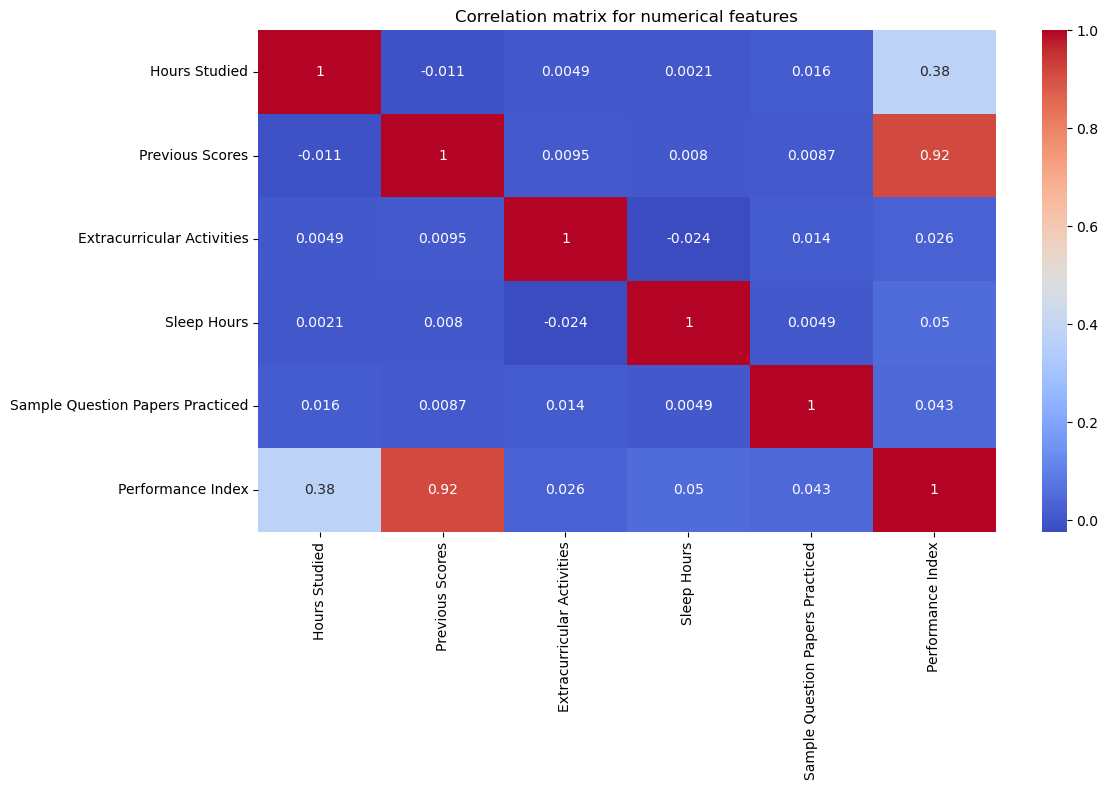

In [40]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation matrix for numerical features')
plt.tight_layout()
plt.show()

**Key Takeaways**
- **Previous Scores** is the **dominant predictor (0.92)**
- **Hours Studied** has meaningful but **secondary influence (0.38)**
- Other features show **weak linear relationships**

In [41]:
x = df[['Hours Studied','Previous Scores']]
y = df[['Performance Index']]

In [42]:
x.head()

,Hours Studied,Previous Scores
0,7,99
1,4,82
2,8,51
3,5,52
4,7,75


In [43]:
y.head()

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0


#### **Split**

In [44]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [45]:
x_train.shape

(7898, 2)

In [46]:
x_test.shape

(1975, 2)

#### **Feature Scaling**
- Split the data first → `train_test_split`
- **Fit** scaler only on **X_train**
- **Transform** both **X_train and X_test**
- Train the model

In [48]:
scaler = StandardScaler()

In [49]:
X_train_scaled = scaler.fit_transform(x_train) # fit & transform the scaler
X_test_scaled = scaler.transform(x_test) # transform 

#### **Train the model**

In [50]:
lr = LinearRegression()

In [51]:
lr.fit(X_train_scaled,  y_train)

LinearRegression()

In [53]:
print('intercept: ', lr.intercept_)
print('co-efficient: ', lr.coef_)

intercept:  [55.09597366]
co-efficient:  [[ 7.3837696  17.62557809]]


#### **Prediction**

In [56]:
y_pred = lr.predict(X_test_scaled)


#### **Evaluation**

In [58]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 1.8798308295705517
MSE: 5.573764139536906
R² Score: 0.9850233951895029
